# Explore here

In [16]:
import pandas as pd
url = "https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv"

df = pd.read_csv(url)
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [17]:
df.shape

(768, 9)

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [19]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [20]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

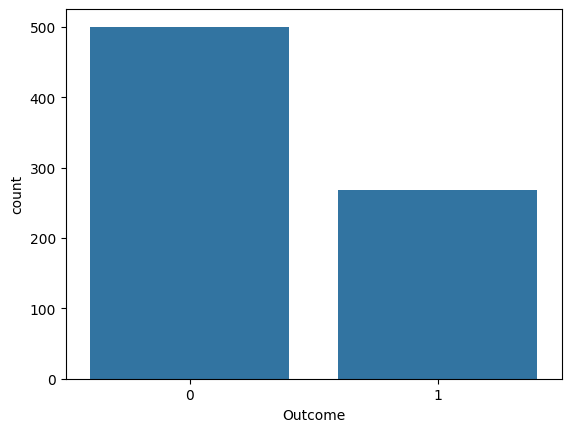

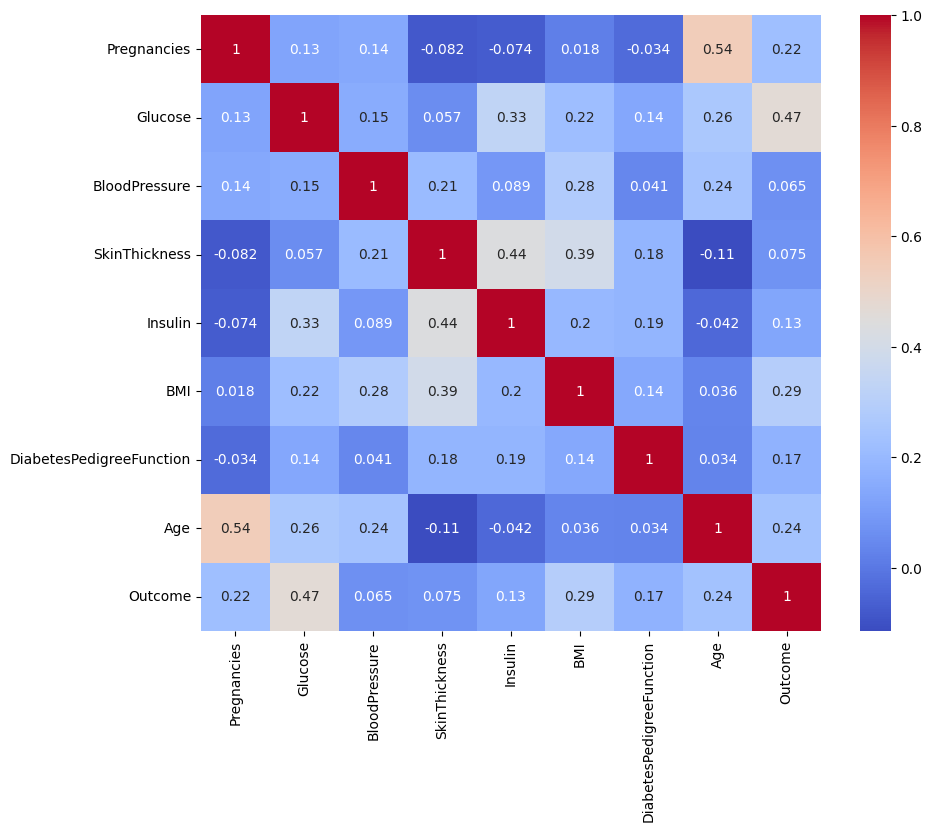

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Outcome", data = df)
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [22]:
from sklearn.model_selection import train_test_split

X = df.drop("Outcome",axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X,y,random_state=42, test_size=0.2
)


[[75 24]
 [15 40]]
              precision    recall  f1-score   support

           0       0.83      0.76      0.79        99
           1       0.62      0.73      0.67        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



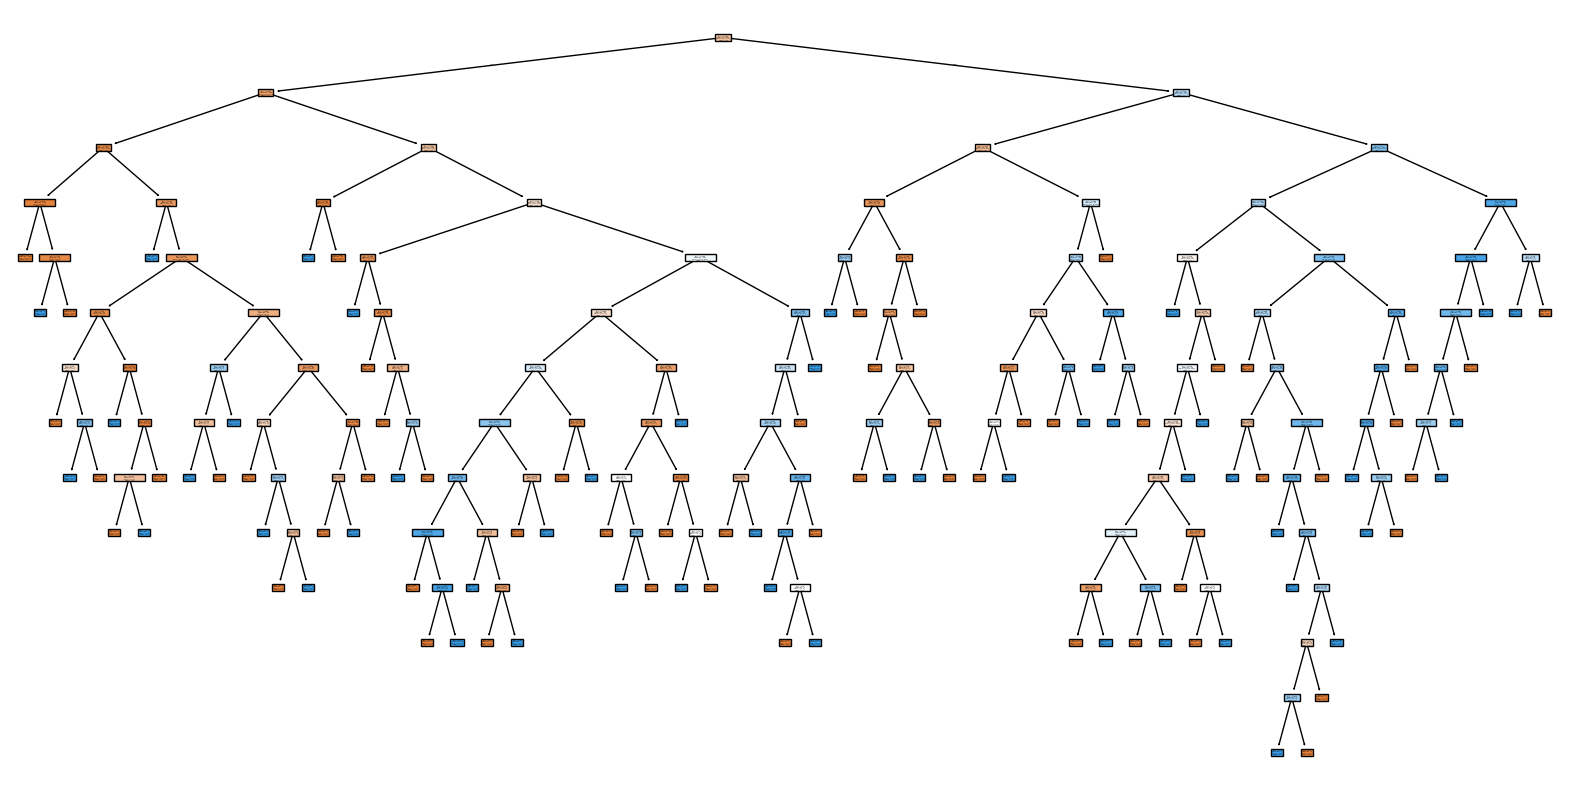

In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn import tree
df = DecisionTreeClassifier(criterion="gini", random_state=42)
df.fit(X_train,y_train)

ypred = df.predict(X_test)

print(confusion_matrix(y_test, ypred))
print(classification_report(y_test, ypred))

plt.figure(figsize=(20,10))
tree.plot_tree(df, feature_names=X.columns, class_names=["yes", "no"],filled=True)
plt.show()

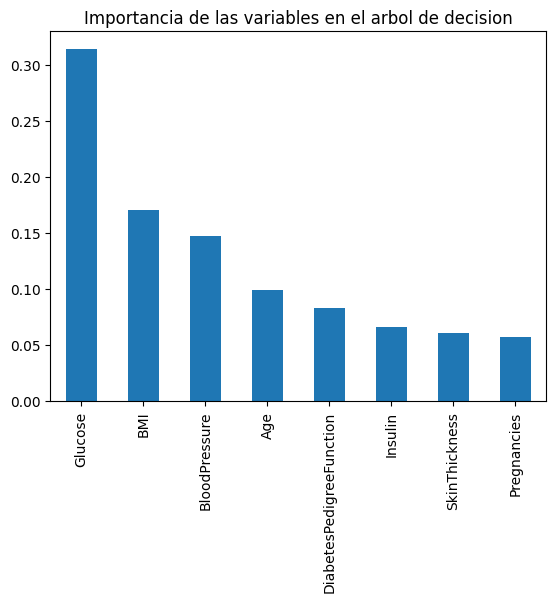

In [24]:
importance = pd.Series(df.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

plt.Figure(figsize=(10,8))
importance.plot(kind="bar")

plt.title("Importancia de las variables en el arbol de decision")
plt.show()

In [25]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [3,5,7,None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4],
    "criterion": ["gini", "entropy"]

}

grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5)
grid.fit(X_train, y_train)

print("mejoresparametros:",grid.best_params_)

best_dt = grid.best_estimator_

y_pred_best = best_dt.predict(X_test)
print(classification_report(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))


mejoresparametros: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 2}
              precision    recall  f1-score   support

           0       0.80      0.84      0.82        99
           1       0.68      0.62      0.65        55

    accuracy                           0.76       154
   macro avg       0.74      0.73      0.73       154
weighted avg       0.76      0.76      0.76       154

              precision    recall  f1-score   support

           0       0.80      0.84      0.82        99
           1       0.68      0.62      0.65        55

    accuracy                           0.76       154
   macro avg       0.74      0.73      0.73       154
weighted avg       0.76      0.76      0.76       154



In [26]:
import joblib   

joblib.dump(best_dt, "../models/diabetes_decision_tree.pkl")

['../models/diabetes_decision_tree.pkl']

Al hacer el arbol pudimos observar que al hacar solo un arbol el accuaracy es mas bajo, al entrenarlo mejor podemos detectar que usando valores mas pequeños en los arboles y un aprendizaje mas lento el accuaracy aumenta, por lo que nos da una respuesta mas acertada para el proyecto, y al notar que los datos en cero se podian mejorar usando el promedio lo use, aunque en la vida real es muy peligroso ya que podria dar falsos negativos y esto podria poner en peligro el diagnostico, tomando en cuenta que detectaria positivos ya diagnosticados en el Xtest, se podria mejorar usando los datos proximos, pero para entender el ejercisio solo ocupo el promedio para no dejar outliners, y para concluir la columna que mas impacta con la deteccion es la glucosa.